# t-SNE projection of Giardia spp. distance matrix

## Introduction


**Aim:**
Subsample a set of Giardia genomes to reduce overrepresentation of highly similar assemblies in a gene-by-gene schema


Project a distance matrix obtained using **mash** (kmer size = 51) to a vector space and then use clustering to determine the similarity among them. Finally, to obtain a curated set of genomes, we will conduct a grouped subsample.

**Data input:**  Import a square matrix of pre-calculated mash distances (*sourmash v4.8.9*) from 88 genome assemblies determined to be of good quality for determining a gene-by-gene schema

The running environment requirements for this notebook are contained in the same folder. By running `conda install --file environment.yml` you will have a conda environment with the necessary dependencies and the kernel for an interactive notebook.

In [1]:
    # Import all dependencies 

import os
import sys
import argparse
import hdbscan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as colormaps
from sklearn.manifold import TSNE
from sklearn.cluster import HDBSCAN
from imblearn.under_sampling import RandomUnderSampler


In [2]:
    # load the curated samples (meeting HQ criteria)   
sour_data = pd.read_csv('../../output/sourmash_HQ_dist.csv', sep=',')

    # sanitize the labels
sour_data.columns = sour_data.columns.str.replace('.*/', '', regex=True)
sour_data.index = sour_data.columns

    # random seed for reproducibility
seed = 112233
    

## t-SNE

### Hyperparameter tuning

This loop will show us different topologies according to the perplexity value (influence of neighbors in clustering). The metric is set to `precomputed` as it comes directly from a MASH square distance matrix. 

I am testing perplexity values below 50, as recommended in the t-SNE method, and evaluating between 250 and 5000 iterations to check convergence. 


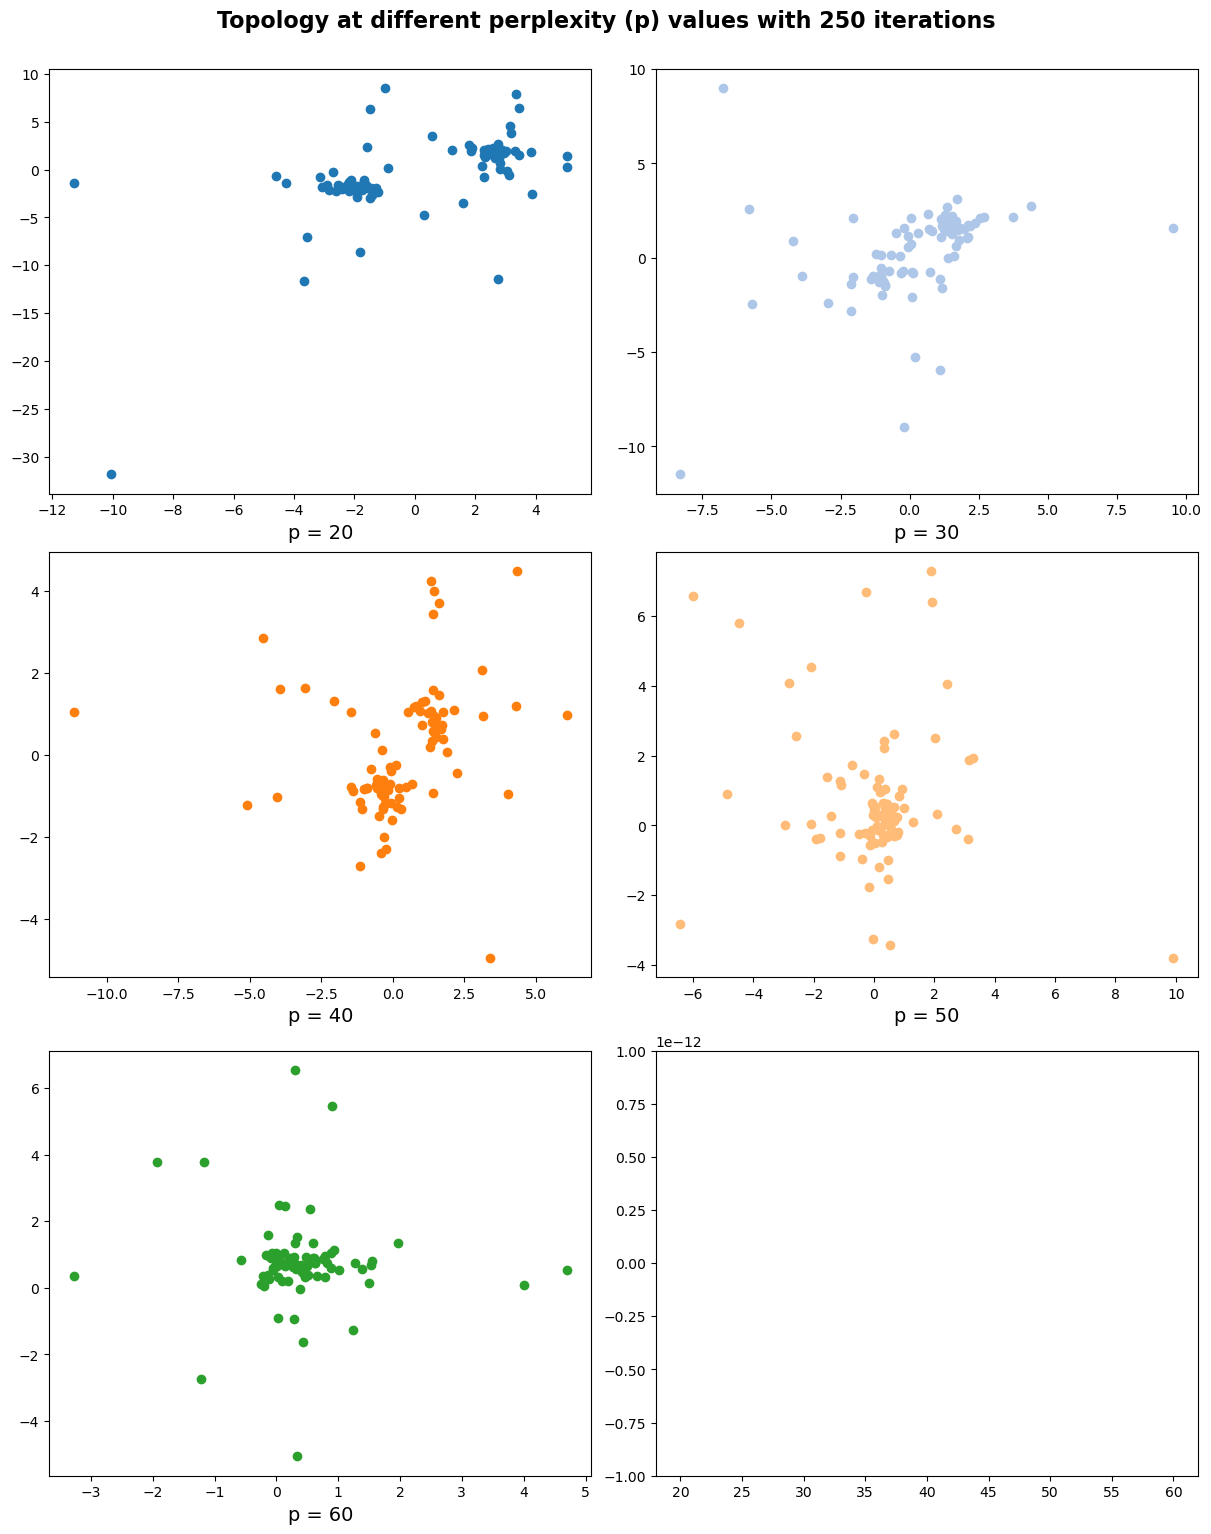

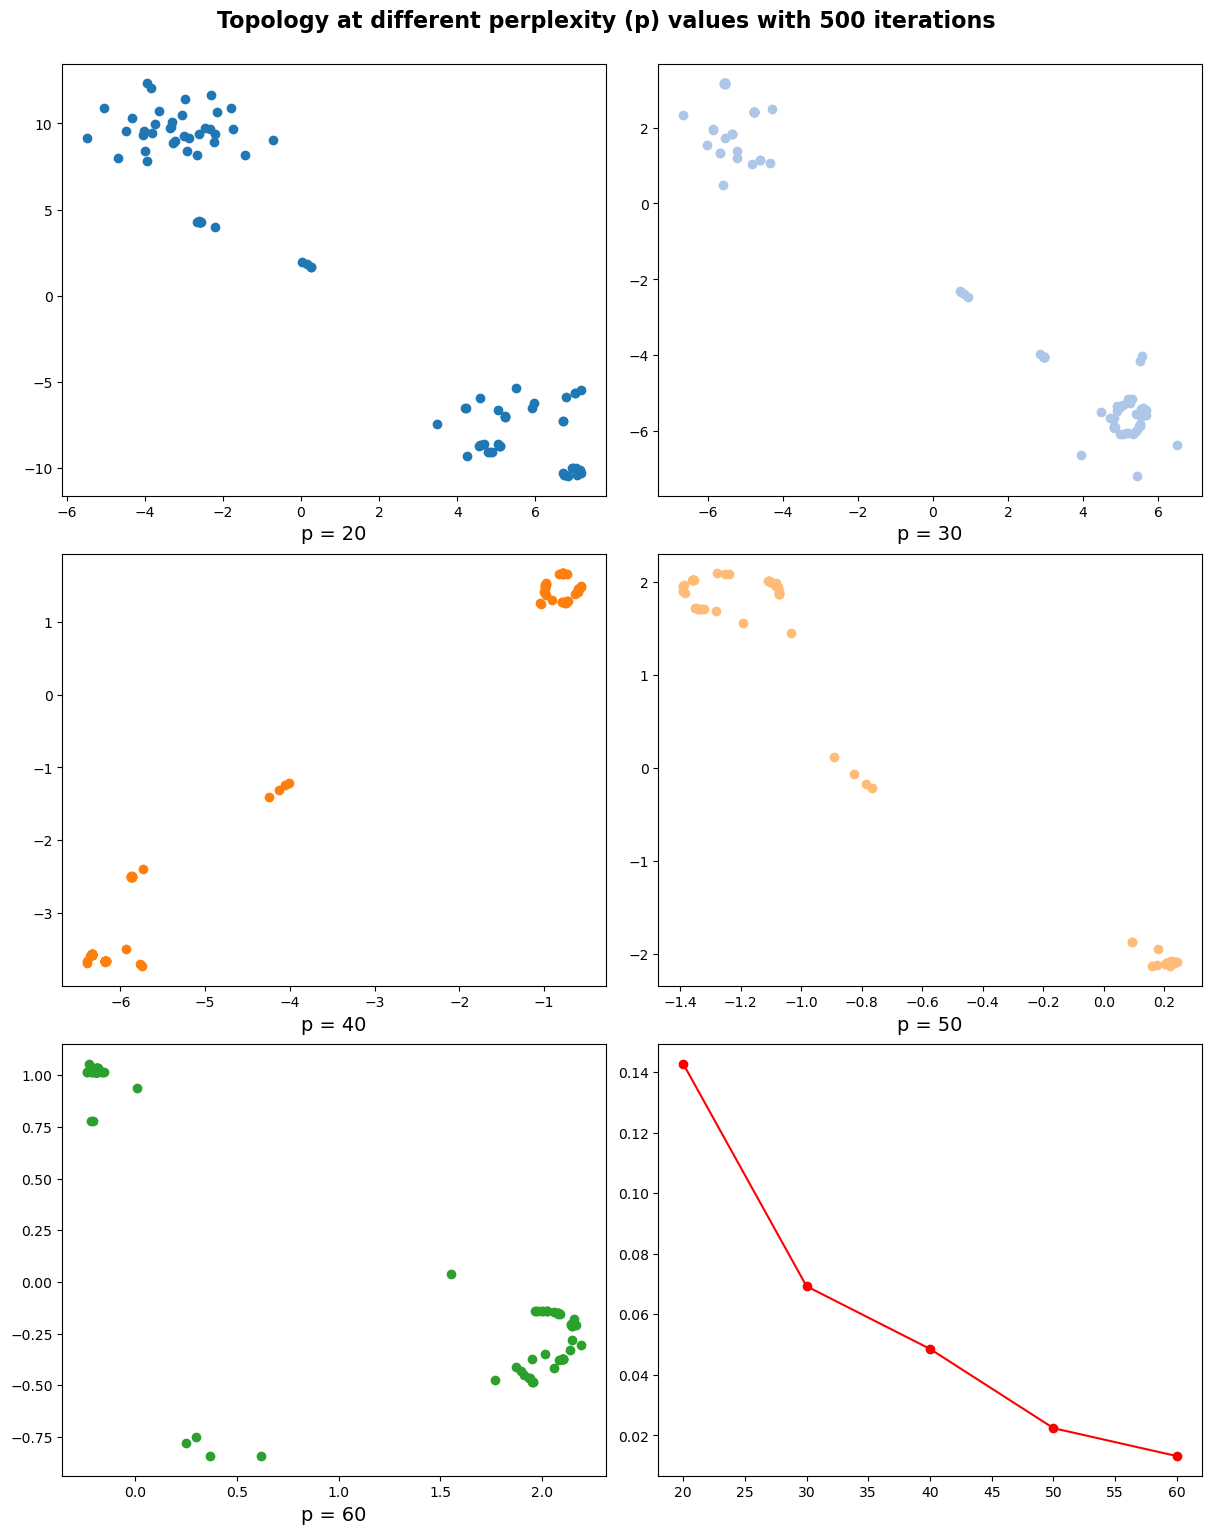

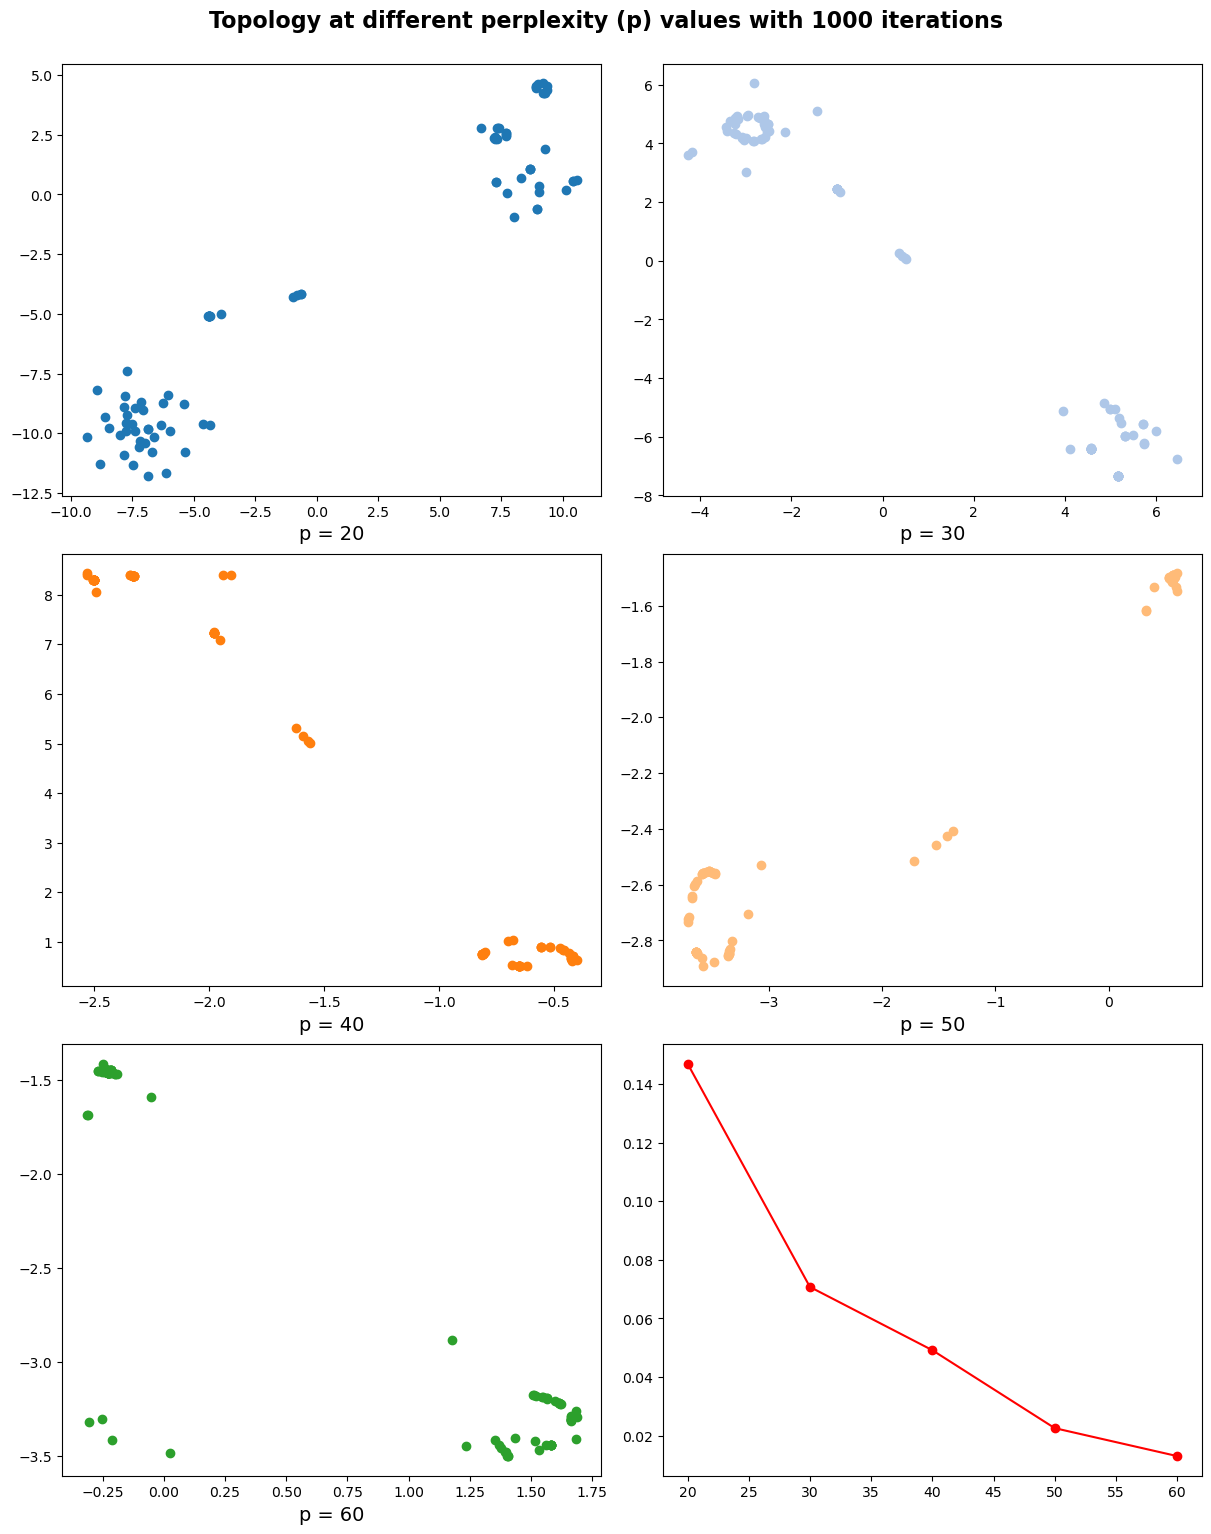

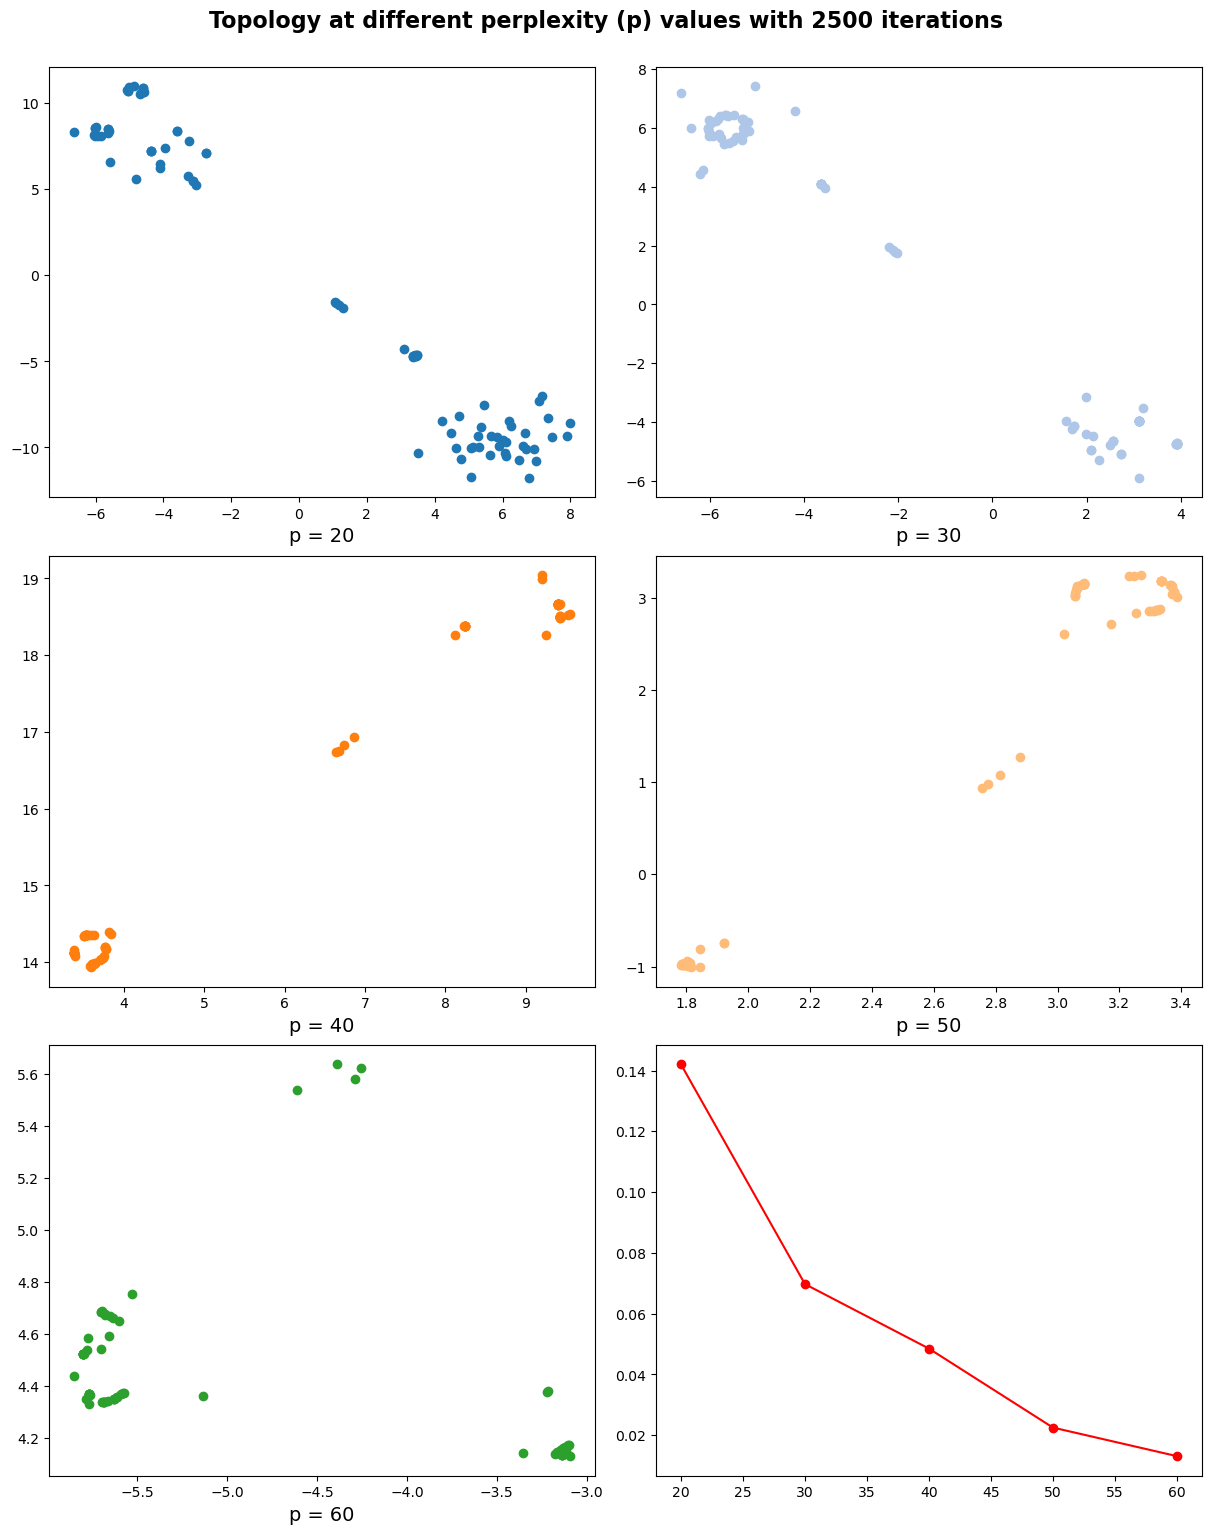

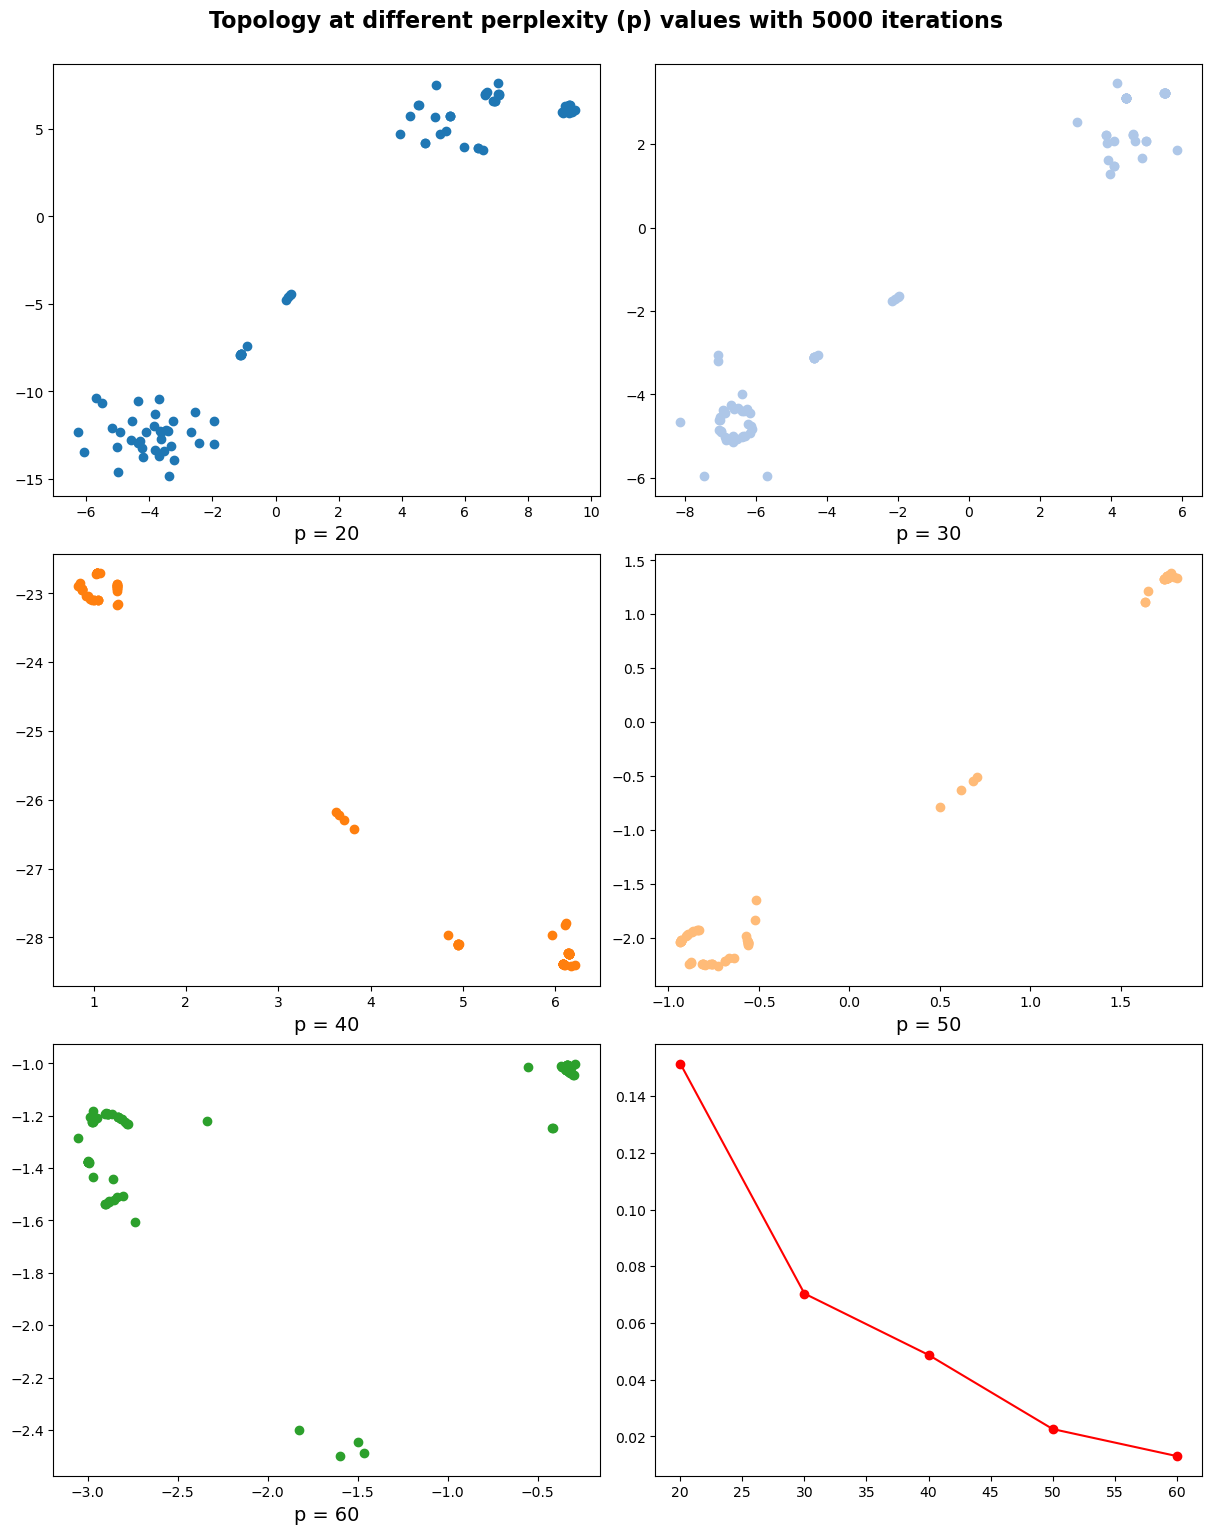

In [3]:
# define range of perplexity and iterations
perplexity = np.arange(20, 62, 10)
iters =  (250, 500, 1000, 2500, 5000)


# produce a multiplot of results by perplexity in the same max_iter value
# capture divergence value for each iteration

for j in iters:
    
    divergence = []        
    fig, axs = plt.subplots(3,2, figsize=(12,15), facecolor='w', layout="constrained")
    fig.suptitle(
        "Topology at different perplexity (p) values with " +
        str(j) + " iterations",  
        fontsize=16, va='bottom', weight='bold'
        ) 
    axs = axs.ravel()

        # pair fit [KL divergence] with perplexity values
    for index, p in enumerate(perplexity):
        
        model = TSNE(
            n_components=2, 
            metric='precomputed', init="random",
            perplexity=p, max_iter=j)
        fitted = model.fit_transform(sour_data)
        divergence.append(model.kl_divergence_)
        
            # plot 2D projections
        axs[index].scatter(fitted[:, 0], fitted[:,1], 
                        color=plt.cm.tab20(index) )
        axs[index].set_xlabel("p = " + str(p),
                            fontsize=14)
        
        # plot perplexity vs KL divergence 
    plt.plot(
        perplexity, divergence, color='red', 
        marker='o', fillstyle='full')

**Note:** your choice of hyperparameter may vary when you run it. 

We find convergence of clustering with at least 1000 iterations using a perplexity value around ~40 when only analyzing the HQ samples. We run this model a few times too to make sure that the same topology is reproduced.

A fitted model embeddings with a random seed (for reproducibility) is saved. Proper labels are attached to this new data frame based on the input data.

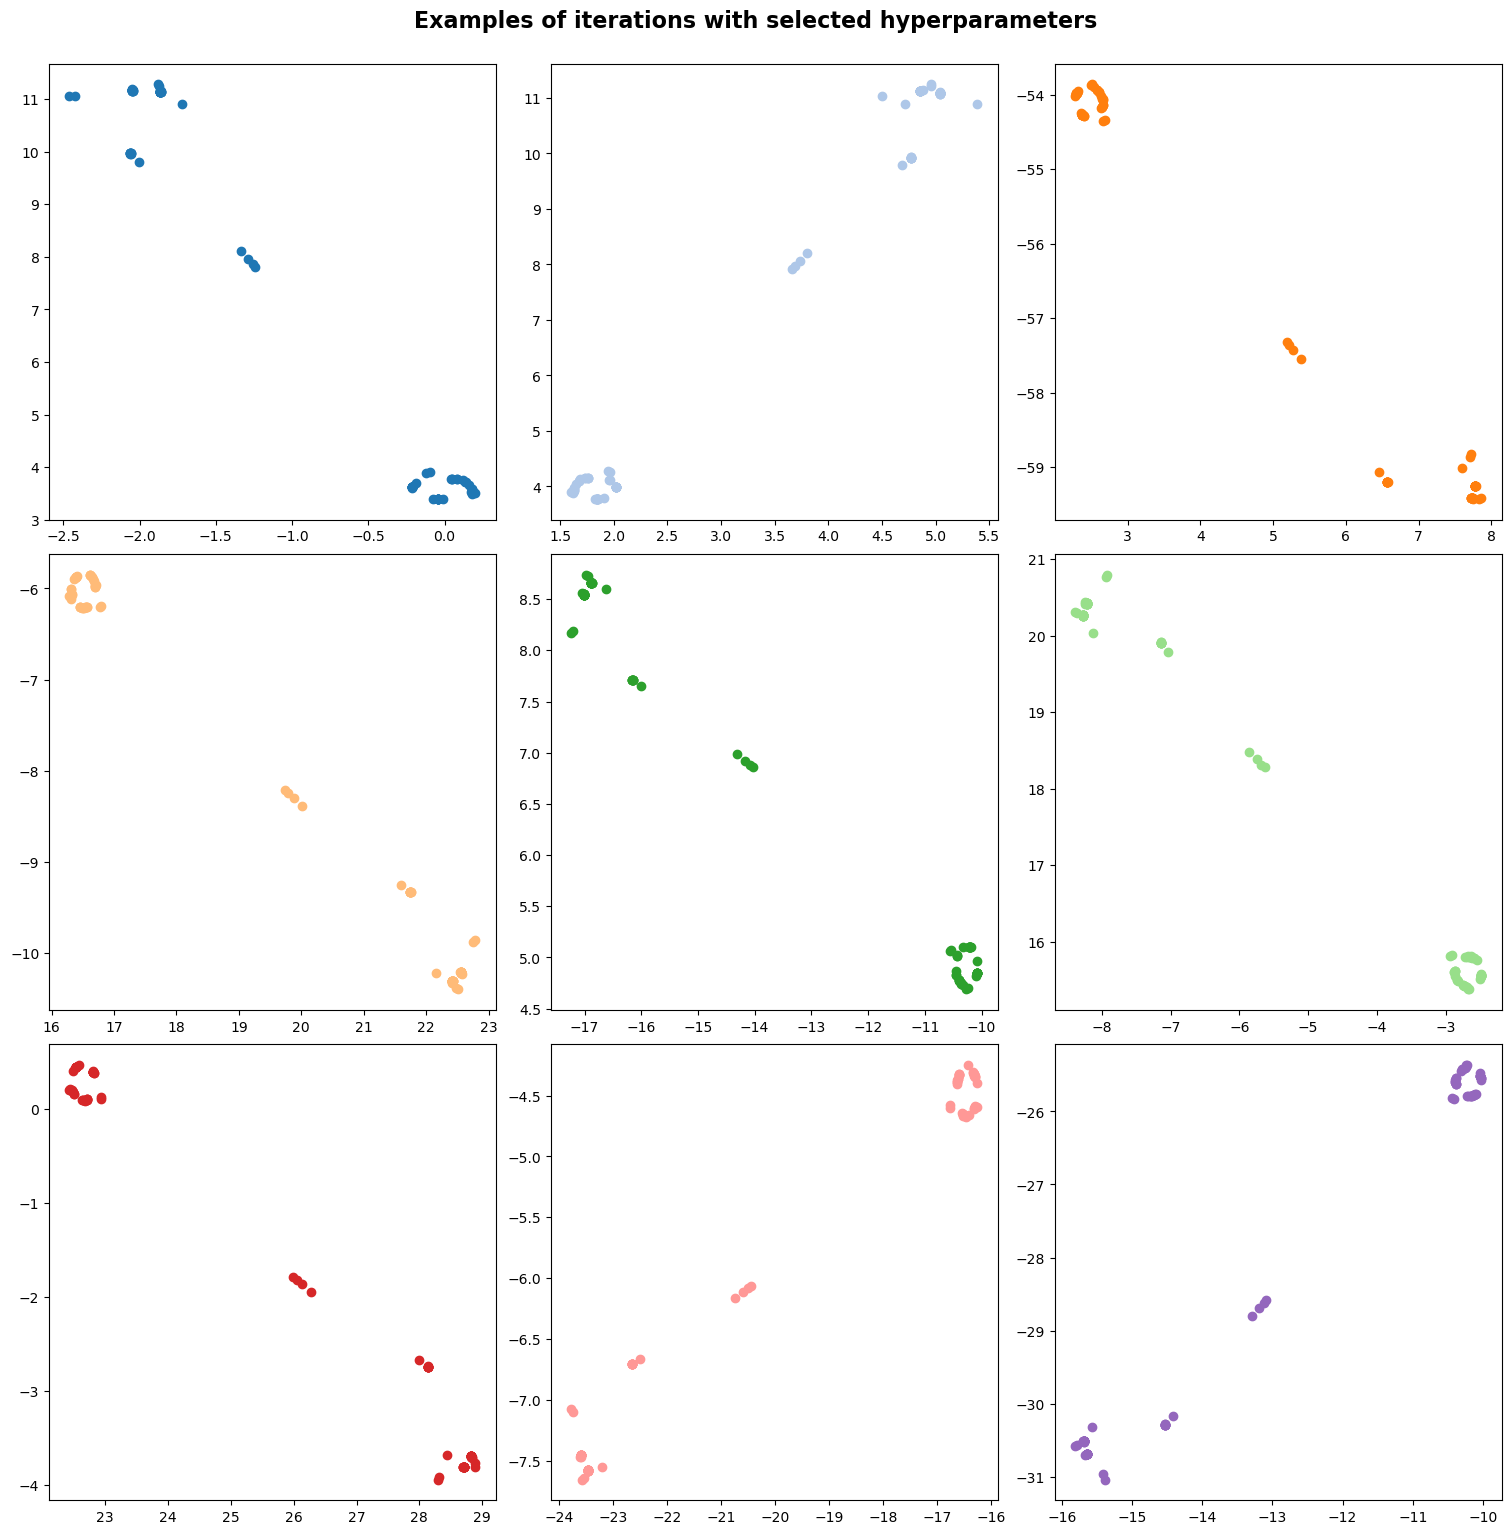

In [4]:

fig, axs = plt.subplots(3,3, figsize=(15,15), 
                facecolor='w', layout="constrained")
fig.suptitle("Examples of iterations with selected hyperparameters",
        fontsize=16, va='bottom', weight='bold') 
axs = axs.ravel()

for index in range(0,9):
        model = TSNE(
                n_components=2, metric="precomputed",
                init="random", perplexity=40,
                max_iter=2500)
        fitted = model.fit_transform(sour_data)
        
        axs[index].scatter(fitted[:, 0], fitted[:, 1],
                           color=plt.cm.tab20(index))

        ## saving embeddings with a seed number
tsne = TSNE(
        n_components=2, random_state=seed, 
        metric='precomputed', init="random",
        perplexity=40, max_iter=2500)
tsne = tsne.fit_transform(sour_data)

vector_mat = pd.DataFrame(tsne, columns=['t-SNE-1', 't-SNE-2'])
vector_mat.index= sour_data.index


## HDBSCAN clustering

### Define a ploting function

Imported and modified the code to plot HDBSCAN results. It takes a numpy array with the clustering labels to produce a scatter plot colored by cluster [if available]. Each point's size represents the probability of belonging to its cluster.

- Unclustered values are marked with a black "X"

In [5]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    
    # transforms if inputs are pd.dataframe so the np operations can be performed
    if isinstance(X, pd.DataFrame):
        X = X.values  
    if isinstance(labels, pd.Series):
        labels = labels.values
    
    # creates a new ploting space if axes is not specified
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 7))
    
    # labels and probabilities are set to "1" if not specified
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    
    # selects colors in spectra palette according to set number
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    # The probability of a point belonging to its labeled cluster determines
        # the size of its marker
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
        class_index = np.where(labels == k)[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=6 if k == -1 else 5 + 7 * proba_map[ci],
            )
    
    # Improve labelling
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" \n {parameters_str}"
    ax.set_title(title,  fontsize=14)
    plt.tight_layout()

### Parameter tuning

**Note:** your choice of this hyperparameter may vary when you run it. 

HDBSCAN will find the optimal epsilon automatically, but we should tune the `min_cluster_size` and the `min_samples` values. 

- We see that small `min_cluster_sizes` (~ 3) are not ideal as they create many small clusters with doubtful separation
- If we go above 30, it fails to select one region with obvious high density
- We want to be somehow conservative and only samples with a definitive association so better to go with an intermediate value like 10 or 15

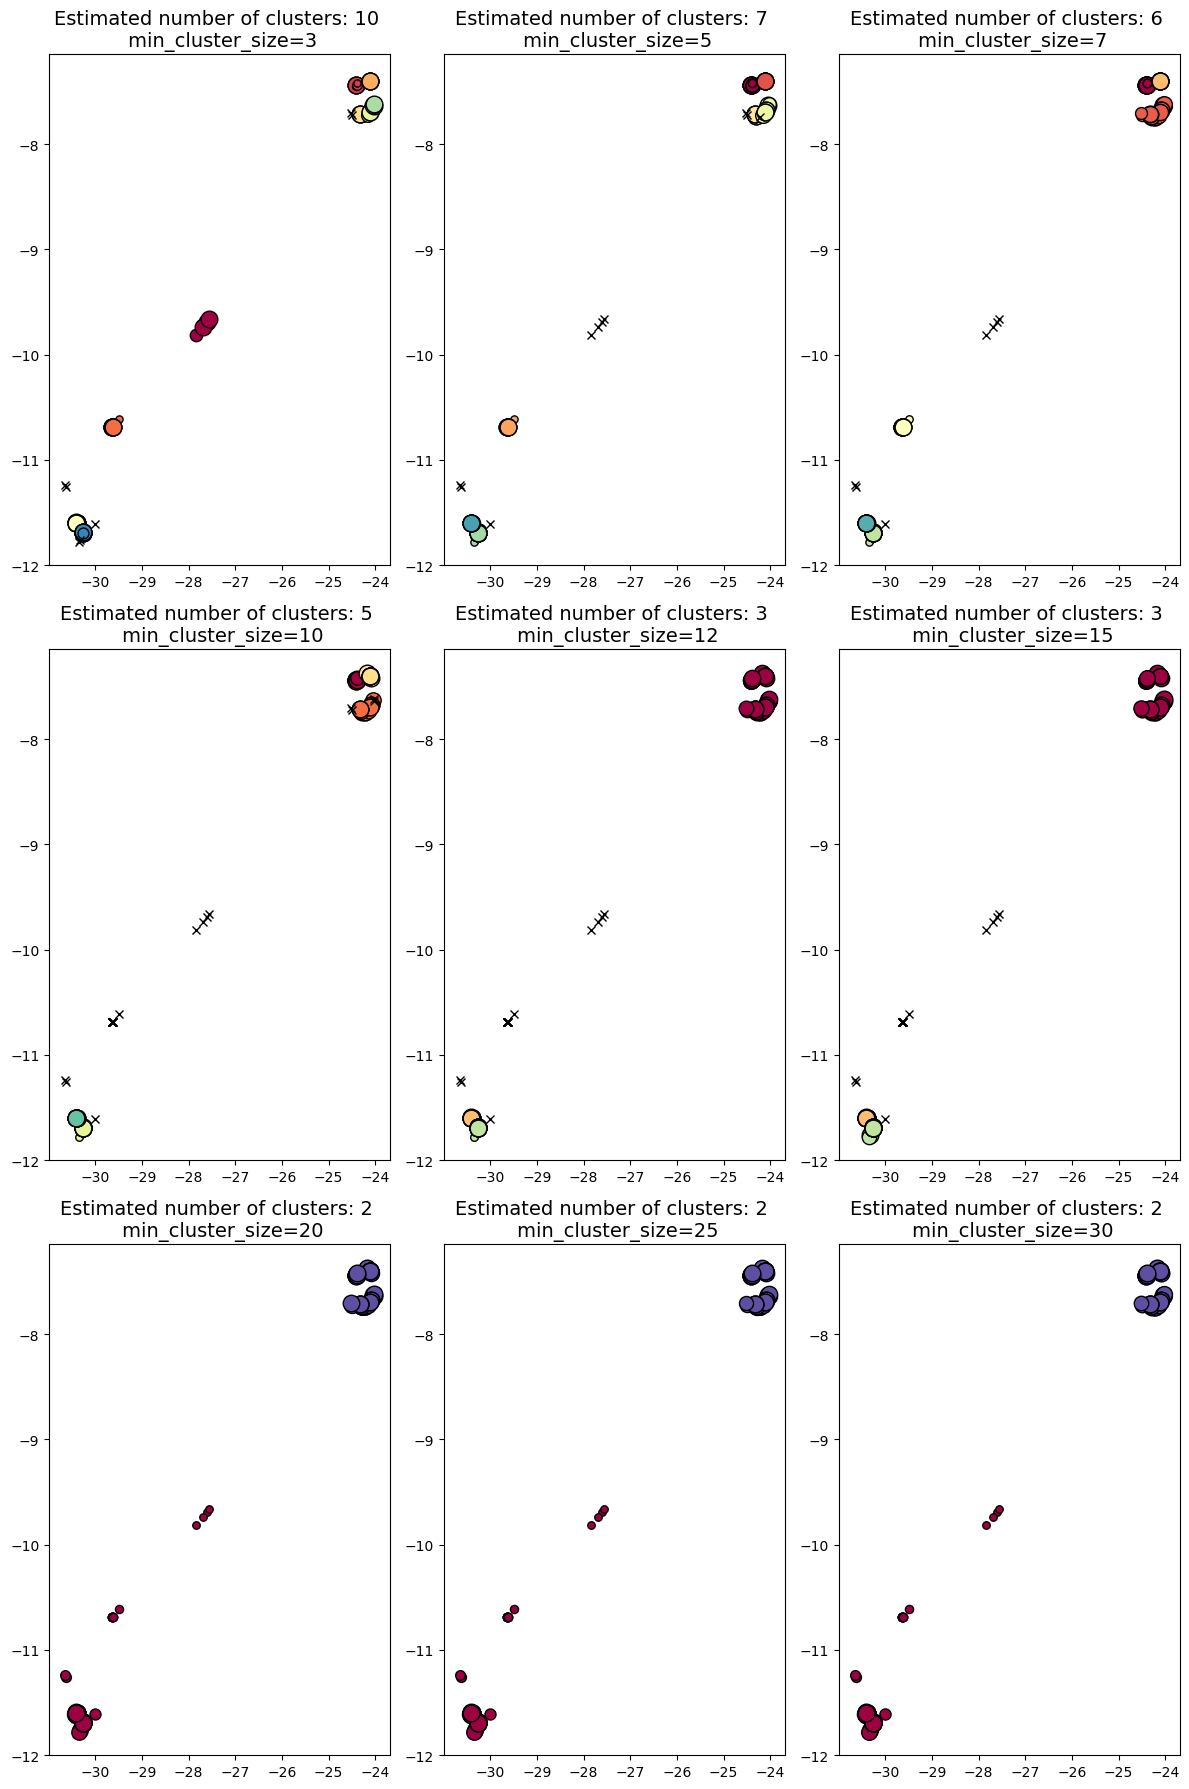

In [6]:
PARAM = ({"min_cluster_size": 3}, {"min_cluster_size": 5}, {"min_cluster_size": 7}, 
         {"min_cluster_size": 10}, {"min_cluster_size": 12}, {"min_cluster_size": 15}, 
         {"min_cluster_size": 20}, {"min_cluster_size": 25}, {"min_cluster_size": 30})

fig, axes = plt.subplots(3, 3, figsize=(12,18))
axes = axes.ravel()

for i, param in enumerate(PARAM):
    hdb = HDBSCAN(algorithm="auto", cluster_selection_method="eom", 
                           **param).fit(vector_mat)
    labels = hdb.labels_
    
    plot(vector_mat, labels, hdb.probabilities_, param, ax=axes[i])
    

Now we will check the importance of `min_samples` with minimum cluster sizes of >10 to define our final grouping approach according to what would be expected from the visualization.



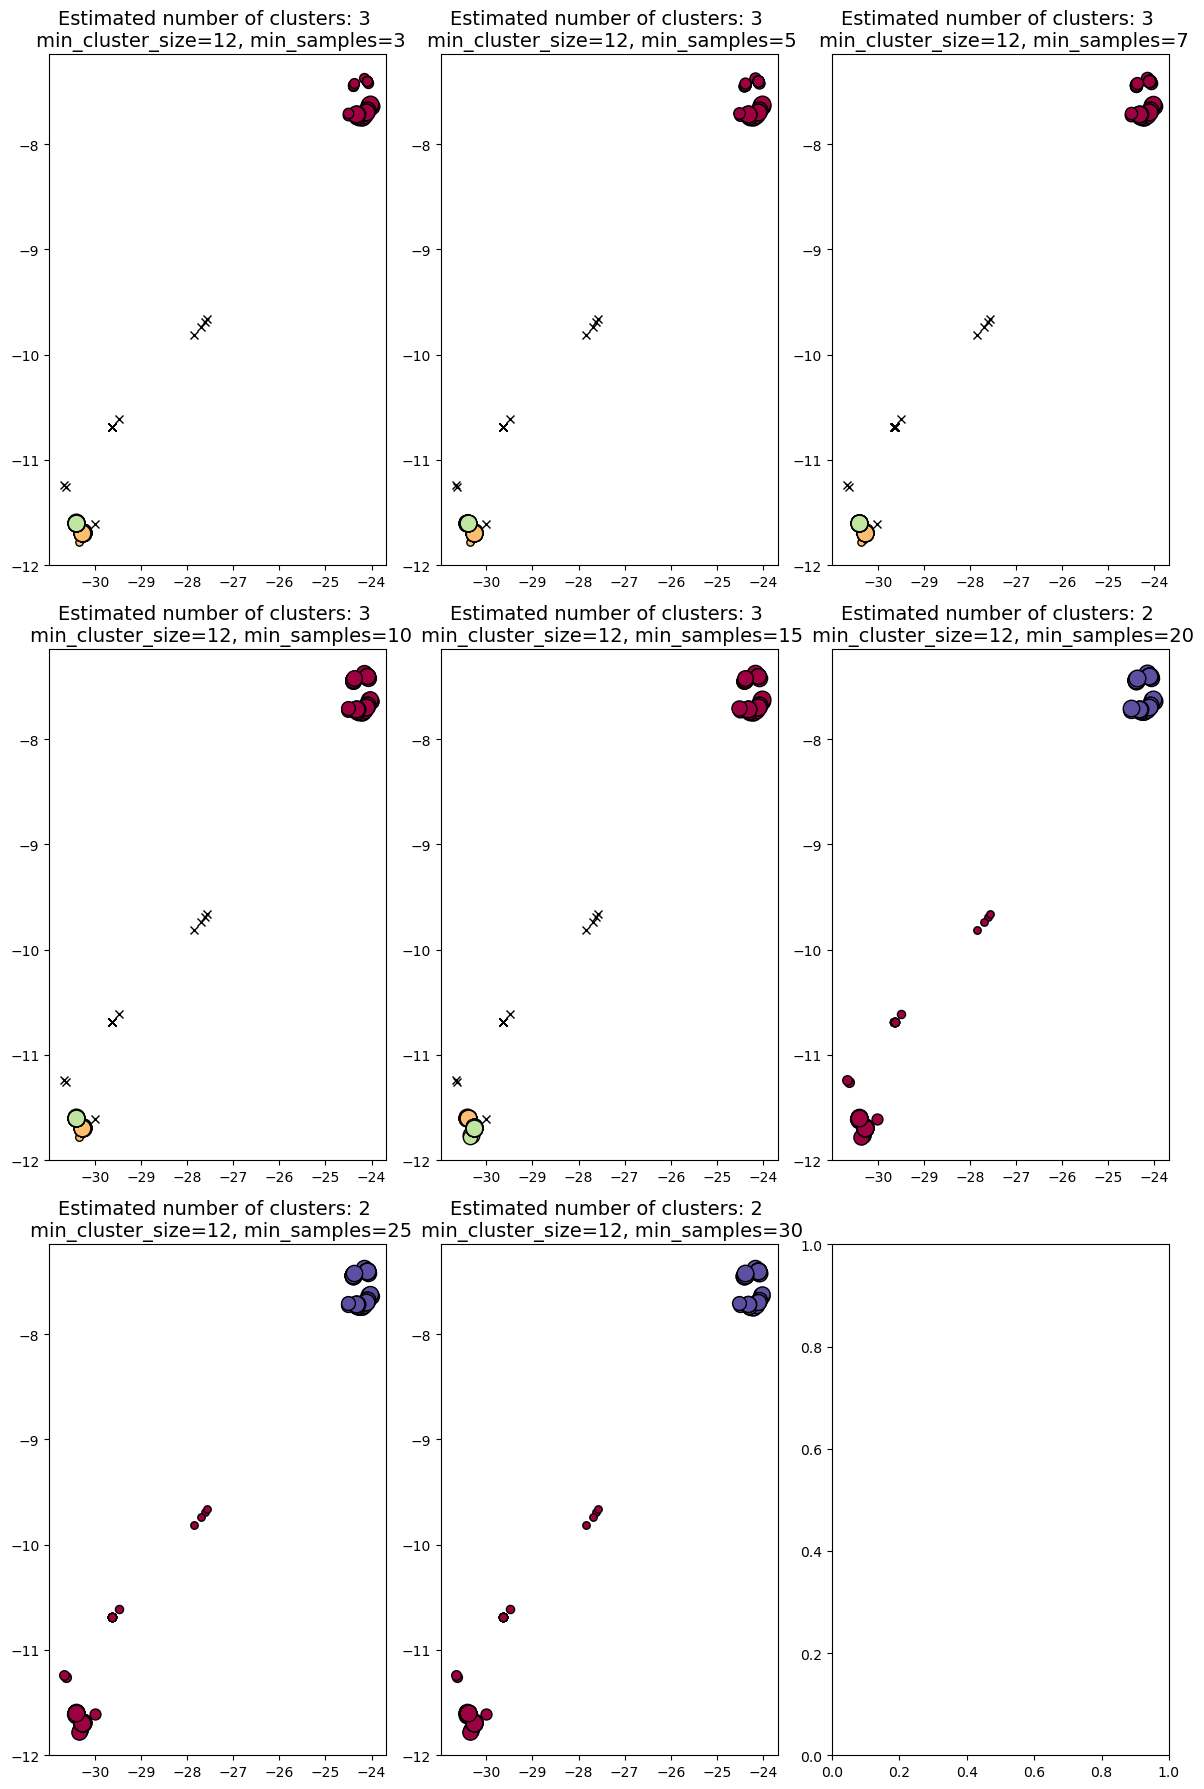

In [7]:
PARAM = (
    {"min_cluster_size": 12, "min_samples": 3}, {"min_cluster_size": 12, "min_samples": 5},
    {"min_cluster_size": 12, "min_samples": 7}, {"min_cluster_size": 12, "min_samples": 10},
    {"min_cluster_size": 12, "min_samples": 15}, {"min_cluster_size": 12, "min_samples": 20}, 
    {"min_cluster_size": 12, "min_samples": 25}, {"min_cluster_size": 12, "min_samples": 30})

fig, axes = plt.subplots(3, 3, figsize=(12,18))
axes = axes.ravel()

for i, param in enumerate(PARAM):
    hdb = HDBSCAN(algorithm="auto", cluster_selection_method="eom",
                  **param).fit(vector_mat)
    labels = hdb.labels_
    
    plot(vector_mat, labels, hdb.probabilities_, param, ax=axes[i])

**Note:** your choice of hyperparameters may vary when you run it. 

We'll go with a `min_cluster_size=12` and `min_samples=10`. 

- The aim is to avoid losing a significant portion of the results 
- We use the implementation in the `hdbscan` module instead of in `sklearn-env` to show the tree-form topology

/home/mdprieto/.conda/envs/tsne/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mdprieto/.conda/envs/tsne/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: ylabel='$\\lambda$ value'>

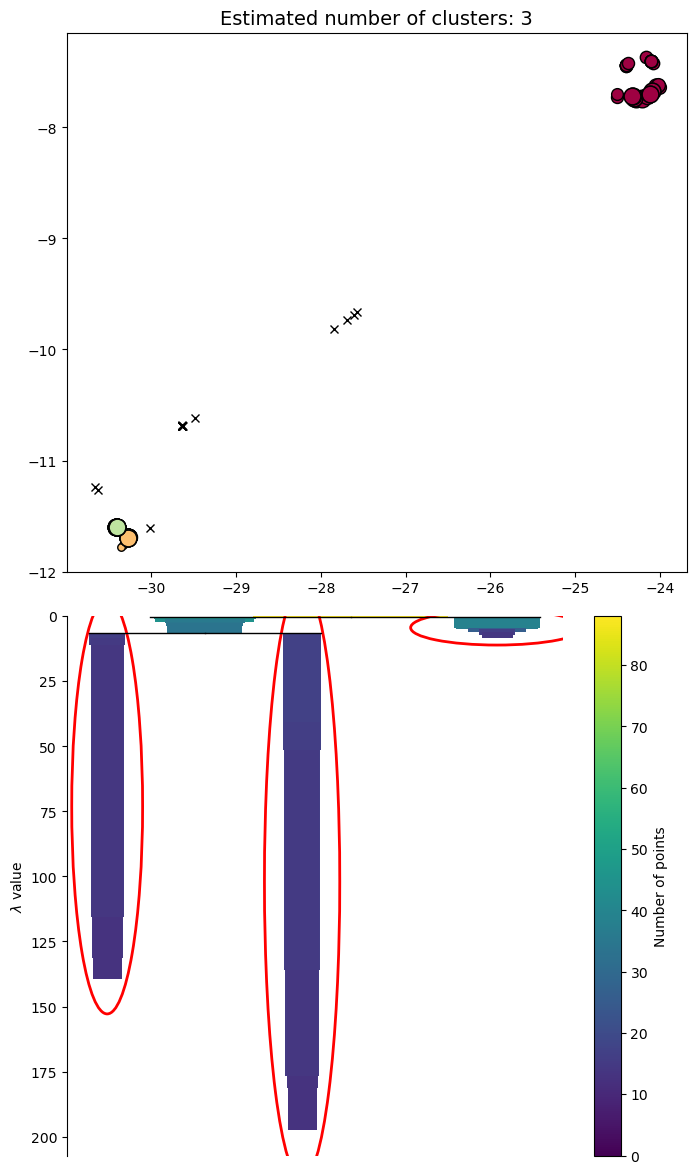

In [8]:
hdb_final = hdbscan.HDBSCAN(algorithm="best", cluster_selection_method="eom",
                            min_cluster_size=12, min_samples=7)

hdb_final = hdb_final.fit(vector_mat)

    # plot the selected clustering and the hierarchical tree
fig, axs = plt.subplots(2, 1, figsize=(7, 12))
plot(vector_mat, hdb_final.labels_, hdb_final.probabilities_, ax=axs[0])
hdb_final.condensed_tree_.plot(select_clusters=True)

## Subsampling informed by clustering

A new dataset with cluster assignment is created for subsampling. To allow visualization of the clustering hierarchy is better to use the library `hdbscan` for the algorithm instead of `sklearn`'s implementation

- Non-clustered samples must be retained so they are extracted from the primary data frame
- We can do stratified sampling of the clustered samples, maintaining the ratio of representation in the primary dataset
- To balance the overrepresentation of certain clusters, it is preferable to do undersampling
    - Here we use the `RandomUnderSampler` method from the module `imbalance-learn`

In [9]:
'''
In case it is necessary to run stratified sampling

vector_mat['hdbscan'] = hdb_final.labels_
vector_mat['cluster'] = vector_mat['hdbscan'].replace(-1, np.nan)

unclustered_df = vector_mat[ vector_mat['hdbscan'].isin([1,2]) ]

strat_sample = (
    vector_mat.groupby('cluster')[['t-SNE-1', 't-SNE-2', 'hdbscan', 'cluster']]
    .apply(lambda x: x.sample(frac=0.7))
    .droplevel(0) 
    )
'''


"\nIn case it is necessary to run stratified sampling\n\nvector_mat['hdbscan'] = hdb_final.labels_\nvector_mat['cluster'] = vector_mat['hdbscan'].replace(-1, np.nan)\n\nunclustered_df = vector_mat[ vector_mat['hdbscan'].isin([1,2]) ]\n\nstrat_sample = (\n    vector_mat.groupby('cluster')[['t-SNE-1', 't-SNE-2', 'hdbscan', 'cluster']]\n    .apply(lambda x: x.sample(frac=0.7))\n    .droplevel(0) \n    )\n"

In [10]:
vector_mat['hdbscan'] = hdb_final.labels_

# sample without replacement, seed for reproducibility
rus=RandomUnderSampler(
    random_state=seed, replacement=False,
    sampling_strategy='auto')

# input whole dataframe and labels
undersampled, labels = rus.fit_resample(vector_mat, vector_mat['hdbscan'])

### Validation and export

Calculate frequency tables showcasing the initial and adjusted distribution of labels.

The data is exported to define the gene-by-gene schema in the `nf_chewbbaca` pipeline

In [11]:
# final frequencies in sample

print(f"Initial matrix")
print(
    vector_mat['hdbscan']
    .replace(-1, "unclustered")
    .value_counts(normalize=True)
    .reset_index(name="Frequency")
    .rename(columns={'hdbscan':'HDBSCAN cluster'})  )

print(f"\nSampled matrix")
print(
    undersampled['hdbscan']
    .replace(-1, "unclustered")
    .value_counts(normalize=True)
    .reset_index(name="Frequency")
    .rename(columns={'hdbscan':'HDBSCAN cluster'})  )

# save only rownames
undersampled.to_csv(
    '../../processed_data/clustered_subsample.txt', 
    sep='\t', 
    header=False, 
    columns=[])


Initial matrix
  HDBSCAN cluster  Frequency
0               0   0.443182
1               2   0.193182
2               1   0.181818
3     unclustered   0.181818

Sampled matrix
  HDBSCAN cluster  Frequency
0     unclustered       0.25
1               0       0.25
2               1       0.25
3               2       0.25
